# House Price Prediction


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Khám phá dữ liệu

In [23]:
df = pd.read_csv("data/housing.csv")
print("Kích thước:", df.shape)
df.head()

Kích thước: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [25]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [26]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

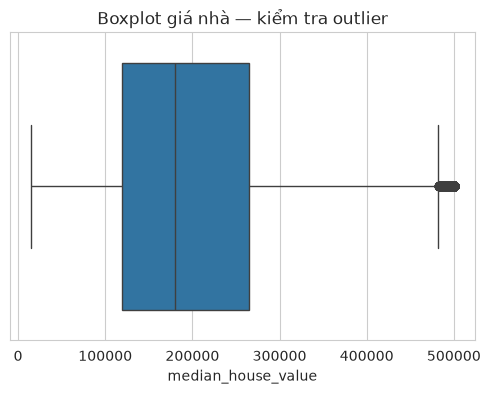

Số dòng giá bị capped ở 500001: 965


In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['median_house_value'])
plt.title('Boxplot giá nhà — kiểm tra outlier')
plt.show()

print('Số dòng giá bị capped ở 500001:', (df['median_house_value'] == 500001).sum())


## 2. Tiền xử lý dữ liệu

### 2.1 Loại bỏ giá trị bị "cắt trần" (capped)
`median_house_value` bị giới hạn ở 500,001 — đây là lỗi thu thập dữ liệu gốc, không phải giá thị trường thật, nên cần loại bỏ để mô hình không học sai.

In [28]:
df = df[df['median_house_value'] < 500001].copy()
print("Kích thước sau khi loại bỏ giá bị capped:", df.shape)


Kích thước sau khi loại bỏ giá bị capped: (19675, 10)


### 2.2 Feature engineering

In [29]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe()


,rooms_per_household,bedrooms_per_room,population_per_household
count,19675.000000,19475.000000,19675.000000
mean,5.360901,0.214975,3.095189
std,2.292538,0.056937,10.631977
min,0.846154,0.100000,0.692308
25%,4.414568,0.177655,2.445486
50%,5.184322,0.204583,2.837134
75%,5.970677,0.240950,3.304894
max,132.533333,1.000000,1243.333333


### 2.3 Kiểm tra đa cộng tuyến (VIF)

Công thức: hồi quy biến đó theo tất cả biến số còn lại, rồi `VIF = 1 / (1 - R²)`.

In [30]:
def compute_vif(X_numeric):
    vif_data = []
    for col in X_numeric.columns:
        other_cols = [c for c in X_numeric.columns if c != col]
        r2 = LinearRegression().fit(X_numeric[other_cols], X_numeric[col]).score(X_numeric[other_cols], X_numeric[col])
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        vif_data.append({'feature': col, 'VIF': vif})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

numeric_check_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                       'total_bedrooms', 'population', 'households', 'median_income',
                       'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

vif_df = compute_vif(df[numeric_check_cols].dropna())
vif_df


,feature,VIF
4,total_bedrooms,50.873537
6,households,45.597744
3,total_rooms,19.337572
1,latitude,9.593819
0,longitude,9.183487
5,population,6.914492
9,bedrooms_per_room,2.787252
7,median_income,2.249413
8,rooms_per_household,1.838822
2,housing_median_age,1.303311


In [31]:
cols_to_drop = ['total_rooms', 'total_bedrooms', 'population', 'households']
df_model = df.drop(columns=cols_to_drop)

# Kiểm tra lại VIF sau khi bỏ cột gốc
remaining_numeric = ['longitude', 'latitude', 'housing_median_age', 'median_income',
                      'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
compute_vif(df_model[remaining_numeric].dropna())


,feature,VIF
1,latitude,9.391222
0,longitude,9.012930
3,median_income,2.088543
5,bedrooms_per_room,1.957320
4,rooms_per_household,1.335690
2,housing_median_age,1.152771
6,population_per_household,1.003030


## 3. Xây dựng pipeline tiền xử lý

In [32]:
numeric_features = remaining_numeric
categorical_features = ['ocean_proximity']

X = df_model[numeric_features + categorical_features]
y = df_model['median_house_value']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])


## 4. Chia tập dữ liệu

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (15740, 8) | Test: (3935, 8)


## 5. Xây dựng mô hình Linear Regression

In [34]:
lin_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lin_pipeline.fit(X_train, y_train)
print('Đã huấn luyện xong.')


Đã huấn luyện xong.


## 6. Đánh giá mô hình

In [35]:
def evaluate(model, X_test, y_test, name='Model'):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'--- {name} ---')
    print(f'MAE  : {mae:,.2f}')
    print(f'RMSE : {rmse:,.2f}')
    print(f'R^2  : {r2:.4f}')
    return y_pred

y_pred_lin = evaluate(lin_pipeline, X_test, y_test, 'Linear Regression')


--- Linear Regression ---
MAE  : 47,286.32
RMSE : 63,662.66
R^2  : 0.5935


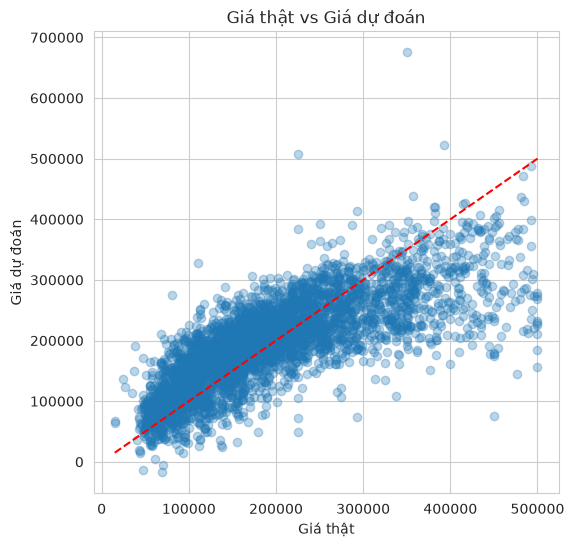

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Giá thật')
plt.ylabel('Giá dự đoán')
plt.title('Giá thật vs Giá dự đoán')
plt.show()


### Residual plot (kiểm tra giả định của Linear Regression)

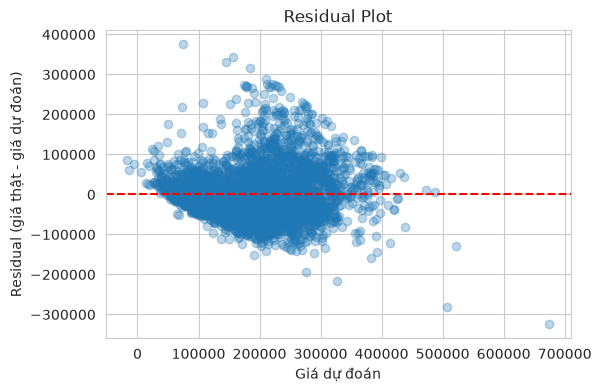

In [37]:
residuals = y_test - y_pred_lin
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lin, residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Giá dự đoán')
plt.ylabel('Residual (giá thật - giá dự đoán)')
plt.title('Residual Plot')
plt.show()


### Cross-validation — đánh giá ổn định hơn

In [38]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lin_pipeline, X, y, cv=kf, scoring='r2')
print('R² từng fold (đã shuffle):', np.round(cv_scores, 4))
print(f'R² trung bình: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')


R² từng fold (đã shuffle): [0.5935 0.5729 0.5949 0.5769 0.603 ]
R² trung bình: 0.5882 (+/- 0.0114)


## 7. Tinh chỉnh mô hình

In [39]:
alphas = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500]}

ridge_pipeline = Pipeline([('preprocessor', preprocessor), ('model', Ridge())])
ridge_grid = GridSearchCV(ridge_pipeline, alphas, cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print('Ridge best alpha:', ridge_grid.best_params_)

lasso_pipeline = Pipeline([('preprocessor', preprocessor), ('model', Lasso(max_iter=10000))])
lasso_grid = GridSearchCV(lasso_pipeline, alphas, cv=5, scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train, y_train)
print('Lasso best alpha:', lasso_grid.best_params_)


Ridge best alpha: {'model__alpha': 0.01}
Lasso best alpha: {'model__alpha': 0.01}


In [40]:
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

_ = evaluate(lin_pipeline, X_test, y_test, 'Linear Regression')
_ = evaluate(best_ridge, X_test, y_test, f"Ridge (alpha={ridge_grid.best_params_['model__alpha']})")
_ = evaluate(best_lasso, X_test, y_test, f"Lasso (alpha={lasso_grid.best_params_['model__alpha']})")


--- Linear Regression ---
MAE  : 47,286.32
RMSE : 63,662.66
R^2  : 0.5935
--- Ridge (alpha=0.01) ---
MAE  : 47,286.24
RMSE : 63,662.47
R^2  : 0.5935
--- Lasso (alpha=0.01) ---
MAE  : 47,286.31
RMSE : 63,662.64
R^2  : 0.5935


## 8. Dự đoán cho nhà mới


In [41]:
new_house = pd.DataFrame([{
    'longitude': -122.23, 'latitude': 37.88, 'housing_median_age': 30,
    'median_income': 5.0,
    'rooms_per_household': 2500/450, 'bedrooms_per_room': 500/2500,
    'population_per_household': 1200/450,
    'ocean_proximity': 'NEAR BAY'
}])[numeric_features + categorical_features]

predicted_price = lin_pipeline.predict(new_house)
print('Giá dự đoán:', round(predicted_price[0], 0), 'USD')


Giá dự đoán: 270537.0 USD


## 9. Lưu mô hình


In [42]:
joblib.dump(lin_pipeline, 'linear_regression_house_price_pipeline.pkl')
print('Đã lưu mô hình.')


Đã lưu mô hình.
